In [1]:
%cd ..

c:\Users\user\OneDrive\Desktop\170A-CHOC


In [2]:
from data.data_partitioner import DataPartitioner

In [3]:
data = DataPartitioner(data_dir='data')
data.load_datasets()

In [4]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

In [35]:
df = data.choc
df_test = data.choc_svi[df.columns.tolist()]
df_eval = data.choc_svi_coi[df.columns.tolist()]

KeyError: "['leaf_id'] not in index"

In [6]:
# Convert categorical feature columns into dummy variables
df_enc = pd.get_dummies(df)
df_test_enc = pd.get_dummies(df_test)
df_eval_enc = pd.get_dummies(df_eval)

In [7]:
# Assuming 'df' is your DataFrame and 'target' is the column you want to predict
X_train = df_enc.drop(['no_show_Yes','no_show_No', 'NOSHOWS_365'], axis=1)
y_train = df_enc['no_show_Yes']
X_test = df_test_enc.drop(['no_show_Yes','no_show_No', 'NOSHOWS_365'], axis=1)
y_test = df_test_enc['no_show_Yes']
X_eval =  df_eval_enc.drop(['no_show_Yes','no_show_No', 'NOSHOWS_365'], axis=1)
y_eval = df_eval_enc['no_show_Yes']

In [8]:
# Initialize the classifier
clf = DecisionTreeClassifier(
    max_depth=2,           # The tree grows until all leaves are pure
    min_samples_split=200,      # The minimum samples required to split a node
    min_samples_leaf=100,       # The minimum samples allowed in a leaf
    max_leaf_nodes=None,       # Unlimited number of leaf nodes
    criterion='gini',
    random_state=42)

# Train the model
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,200
,min_samples_leaf,100
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


              precision    recall  f1-score   support

       False       0.88      1.00      0.94     27089
        True       0.89      0.07      0.13      3888

    accuracy                           0.88     30977
   macro avg       0.89      0.53      0.53     30977
weighted avg       0.88      0.88      0.84     30977



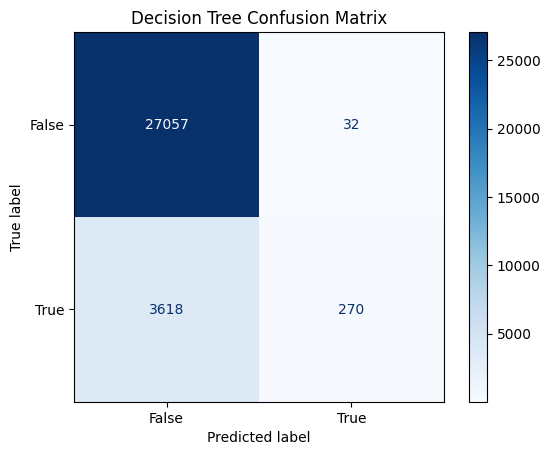

In [9]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred=clf.predict(X_train)
print(classification_report(y_train, y_pred))
# 2. Compute the confusion matrix
cm = confusion_matrix(y_train, y_pred)

# 3. Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Decision Tree Confusion Matrix")
plt.show()

              precision    recall  f1-score   support

       False       0.90      1.00      0.95     60672
        True       0.87      0.08      0.15      7519

    accuracy                           0.90     68191
   macro avg       0.89      0.54      0.55     68191
weighted avg       0.90      0.90      0.86     68191



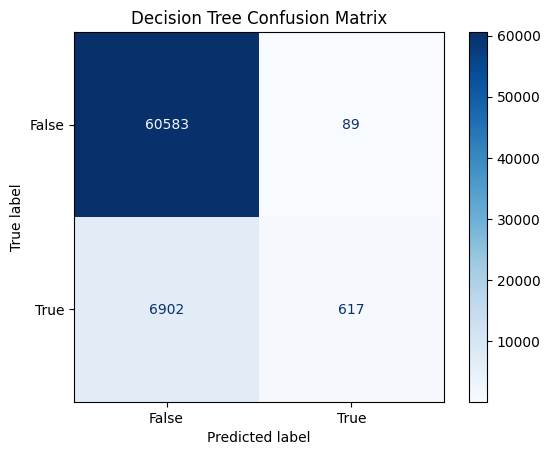

In [10]:
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
# 2. Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Decision Tree Confusion Matrix")
plt.show()

              precision    recall  f1-score   support

       False       0.88      1.00      0.94    401736
        True       0.86      0.04      0.08     57649

    accuracy                           0.88    459385
   macro avg       0.87      0.52      0.51    459385
weighted avg       0.88      0.88      0.83    459385



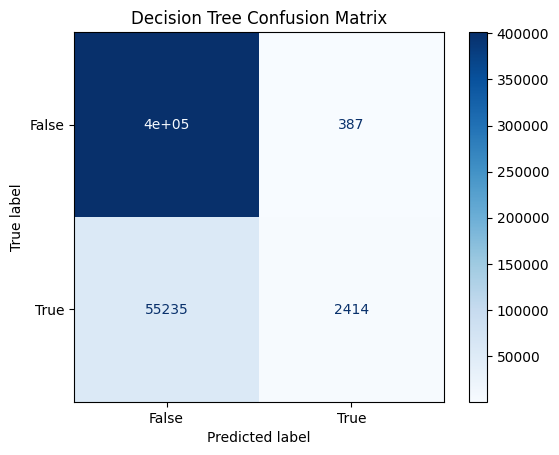

In [11]:
y_pred=clf.predict(X_eval)
print(classification_report(y_eval, y_pred))
# 2. Compute the confusion matrix
cm = confusion_matrix(y_eval, y_pred)

# 3. Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [12]:
from sklearn.tree import export_text

# show_weights=True adds the counts for each class
rules = export_text(clf, feature_names=list(X_train.columns), show_weights=True)
print(rules)

|--- INSURANCE_TYPE_Other/Unknown <= 0.50
|   |--- INSURANCE_TYPE_Commercial <= 0.50
|   |   |--- weights: [11038.00, 2047.00] class: False
|   |--- INSURANCE_TYPE_Commercial >  0.50
|   |   |--- weights: [15914.00, 1483.00] class: False
|--- INSURANCE_TYPE_Other/Unknown >  0.50
|   |--- PRIMARY_CARE_365 <= 0.50
|   |   |--- weights: [105.00, 88.00] class: False
|   |--- PRIMARY_CARE_365 >  0.50
|   |   |--- weights: [32.00, 270.00] class: True



In [20]:
# Assuming your column name is 'noshow' and values are 'Yes'/'No'
summary_df = df.pivot_table(
    index=['age', 
           'GENDER', 
           'RACE', 
           'ETHNICITY',
           'MOBILITY_ABILITY_DX_IND',
           'MENTAL_HEALTH_DX_IND',
           ], 
    columns='no_show', 
    aggfunc='size', 
    fill_value=0
).reset_index()

# Rename columns for clarity
summary_df.columns.name = None
summary_df = summary_df.rename(columns={'No': 'indv_noshow_no', 'Yes': 'indv_noshow_yes'})

In [21]:
summary_df.shape

(1275, 8)

In [25]:
# Assuming 'clf' is your trained DecisionTreeClassifier
# and 'X' is the feature set used for that tree
df['leaf_id'] = clf.apply(X_train)

In [26]:
# 1. Total count per leaf group
leaf_counts = df.groupby('leaf_id').size().rename('total_group_count')

# 2. Breakdown of shows vs no-shows per leaf
# Assuming 'noshow' column has values 'Yes' and 'No'
leaf_stats = df.groupby(['leaf_id', 'no_show']).size().unstack(fill_value=0)

# Rename columns for clarity
leaf_stats = leaf_stats.rename(columns={'No': 'group_show_count', 'Yes': 'group_noshow_count'})

In [27]:
# Join the total counts
df = df.merge(leaf_counts, on='leaf_id', how='left')

# Join the show/no-show breakdown
df = df.merge(leaf_stats, on='leaf_id', how='left')

# Optional: Calculate the probability/rate for that group
df['group_noshow_rate'] = df['group_noshow_count'] / df['total_group_count']

In [29]:
df_final = df.merge(summary_df, on= ['age', 
           'GENDER', 
           'RACE', 
           'ETHNICITY',
           'MOBILITY_ABILITY_DX_IND',
           'MENTAL_HEALTH_DX_IND',
           ], how='left')

In [45]:
def feature_eng(df, summary_df, clf, leaf_stats,  X_eval):
    nndf = df.merge(summary_df, on= ['age', 
           'GENDER', 
           'RACE', 
           'ETHNICITY',
           'MOBILITY_ABILITY_DX_IND',
           'MENTAL_HEALTH_DX_IND',
           ], how='left')
    nndf['leaf_id'] = clf.apply(X_eval)
    nndf = nndf.merge(leaf_stats, on='leaf_id', how='left')
    return nndf.drop(columns=['leaf_id','age', 
           'GENDER', 
           'RACE', 
           'ETHNICITY',
           'MOBILITY_ABILITY_DX_IND',
           'MENTAL_HEALTH_DX_IND','INSURANCE_TYPE','PRIMARY_CARE_365'])

In [47]:
engineered_data = feature_eng(data.choc_svi_coi,summary_df,clf,leaf_stats, X_eval)

In [50]:
engineered_data.to_csv('data/no_beta_engineered_data.csv')